MachineLearning을 위한 기본 컨셉을 예제를 통해 실습해본다.(2026/03/10 실습)
-경사하강법]
- y=1+2x 세타 0 =1, 세타 1 = 2
1. 데이터를 직접 만든다
2. 그래프로 데이터를 본다
3. train / validation 데이터를 나눈다
4. AI가 직선을 학습한다
5. 오차(loss)를 줄인다
6. 경사하강법으로 최적의 직선을 찾는다
7. sklearn과 비교한다
8. PyTorch Tensor까지 연결한다

※ 우리가 풀 문제 : 우리는 이런 데이터를 가지고 있다고 생각해보자.
공부시간(x)	시험점수(y)
1시간	3점
2시간	5점
3시간	7점

우리는 AI에게: "공부시간을 보면 점수를 예측하게 만들어라!" 를 시키는 거야.

선형회귀란? 데이터를 가장 잘 설명하는 직선을 찾는 것 / a: 시작점(절편), b: 기울기, x: 입력, y: 예측값

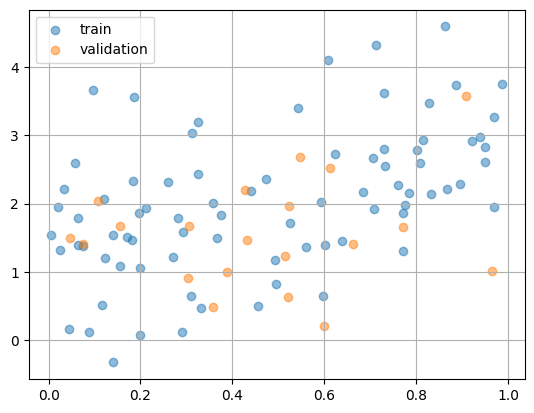

LinearRegression with Numpy: [0.49671415] [-0.1382643]
epoch: [1.23540769] [1.68964442]
sklearn.linear_model :  [1.23540755] [1.6896447]
torch: tensor([1.1510], requires_grad=True) tensor([0.1871], requires_grad=True)


In [3]:
#import sys
#!{sys.executable} -m pip install torch

import numpy as np   
import matplotlib.pyplot as plt

#Data generation
np.random.seed(42)
x= np.random.rand(100,1)
y=1+2*x+1*np.random.randn(100,1)  #렌덤 노이즈를 추가한 이유 : 현실데이터는 완벽하지 않아서..

#Shuffles the indices
idx = np.arange(100)
np.random.shuffle(idx)

# Uses first 80 random indices for train ==> 훈련하기 위해서
train_idx = idx[:80]

# Uses the remaining indices for validation ==>  나머지는 검증용 validation데이타
val_idx = idx[80:]

# train을 위하 x, y에 값넣기 - 실제 데이터 넣기
x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

# 그런 다음 plot으로 띄우기
fig, ax = plt.subplots()
ax.scatter(x_train, y_train, color = 'C0', label = 'train', alpha = 0.5)  # 파란색 : 공부데이터
ax.scatter(x_val, y_val, color = 'C1', label = 'validation', alpha = 0.5) # 주황색 : 시험데이터
ax.legend()
ax.grid(True)
plt.show()

#LinearRegression with Numpy ==> learning mate : 에러값이 나올때 에러값을 반영할 때 곧이곧대로 반영하면 강하게 파라메터가 바뀌니까, 감쇠를 시켜준다.
# ai가 직선을 찾는다. --> 처음에는 아무직선 한개를 고른다 : y=-3+8x
np.random.seed(42)
a = np.random.randn(1)
b = np.random.randn(1)
print("LinearRegression with Numpy:", a,b)              #[0.49671415] [-0.1382643]

# Sets learning rate
lr = 1e-1  # 1r=1e-1 => 0.1  --> 조금씩 수정할까? 엄청 크게 수정할까? 너무 크면 산 내려가다가 절벽 뛰어넘는꼴이고 너무 작으면 너무 느리게 가는것이다.

# epochs : 1000번 반복한다. 반복횟수
# Defines number of epochs
n_epochs = 1000   # 문제를 몇 번 다시 풀것인가를..몇 번 반복 학습을 할것인가

for epoch in range(n_epochs):
    # Computes our model's predicted output
    yhat = a+b*x_train   # AI가 현재 생각하는 직선 

    #How wrong is our model? That's the error!
    error = (y_train - yhat) # 얼마나 틀렷을 지를 구한다 : 실제값-예측값

    # It is a regression, so it computes mean squared error(MSE)
    loss = (error **2).mean()  # loss값을 구한다, 음수제거 + 큰 오차 더 강하게 벌주기 , 오차1 --> 1, 오차 5--> 25

    #******************************************
    #Computes gradients for both "a" and "b" parameters --> 어느 방향으로 수정해야 LOSS가 줄어드는가?, LOSS가 내려가는 방향 찾기

    a_grad = -2 * error.mean()
    b_grad = -2 * (x_train*error).mean()  
    #Updates parameters using gradients and the learning rate
    a = a - lr*a_grad
    b = b - lr*b_grad

    #******************************************
    # 전체적인 흐름 : 예측->오차계산->기울기계산->파라미터수정->반복

print("epoch:", a,b)  # [1.23540769] [1.68964442]

#아래 실제 머신러닝 돌리는 코드
#Sanity check : do we get the same results as our gradient desecnt?
from sklearn.linear_model import LinearRegression
linr = LinearRegression()
linr.fit(x_train, y_train)
print("sklearn.linear_model : ", linr.intercept_, linr.coef_[0])  #[1.23540755] [1.6896447]
# 우리가 직접 만든 선형회귀와 실제 라이브러리 결과 비교.
# 위의 두 예제를 통해 우리가 만든 AI와 실제 머신러닝 라이브러리가 같음을 알자~

#CUDA : GPU를 쓸지 말지를 결정
# parameter용 텐서
# Tensor란? 딥러닝에서 사용하는 특별한 배열. GPU 연산 가능 + 자동미분 가능.
# 1. GPU 사용 2. Tensor 생성 3. numpy → tensor 변환 4. 자동미분(autograd) 5. 학습할 변수(weight) 생성
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# -----------------------------------------
# numpy 배열 -> PyTorch Tensor 변환 
# -----------------------------------------
# x_train은 원래 numpy 배열이다. 딥러닝(PyTorch)은 Tensor를 사용해야 한다.
# tensor는: # - GPU 사용 가능 # - 자동미분 가능 # - 딥러닝 계산 최적화
# torch.from_numpy(...) # -> numpy 배열을 tensor로 바꾼다.
# -----------------------------------------
# float() 설명
# -----------------------------------------
# 딥러닝에서는 보통 float32 타입 사용 #
# 예: # int(정수) # 1,2,3 # float(실수) # 1.2, 3.14
# 신경망 weight 계산은 대부분 실수 계산이므로 float로 바꾸는 것이 중요하다.
# -----------------------------------------
# to(device) 설명
# -----------------------------------------
# tensor를 CPU 또는 GPU로 이동 # device가 cuda이면 GPU 메모리로 이동 # 즉: # CPU tensor -> GPU tensor
# -----------------------------------------
# y_train도 동일하게 처리
# -----------------------------------------
# y_train_tensor = torch.from_numpy(y_train) # y_train_tensor = y_train_tensor.float() #y_train_tensor = y_train_tensor.to(device)
# -----------------------------------------

x_train_tensor = torch.from_numpy(x_train).float().to(device)
y_train_tensor = torch.from_numpy(y_train).float().to(device)

# -----------------------------------------
# 다시 numpy로 변환
# -----------------------------------------
# GPU tensor는 numpy로 바로 변환 불가능  # 그래서: # 1. cpu()로 CPU 이동  # 2. numpy()로 numpy 배열 변환

x_train_numpy = x_train_tensor.cpu().numpy()

# weighht용 텐서는 값을 업데이트 할 수 있어야 한다.
#  torch.randn(1, requires_grad=True) : "이 변수는 자동으로 미분 추적해줘!"
# 딥러닝의 미분 : → gradient 계산 → weight 수정

# -----------------------------------------
# 학습할 파라미터(weight) 생성
# -----------------------------------------
# torch.randn(1) # randn = random normal # 평균 0, 표준편차 1
# 정규분포 랜덤값 생성 # 예: # tensor([0.3367]), # tensor([-1.1234])
# -----------------------------------------
# a 생성
# -----------------------------------------
#a = torch.randn(
#    1,                  # 생성할 tensor 크기(shape) # 여기서는 숫자 1개 생성
#    requires_grad=True, # 자동 미분 추적 여부        # True이면 gradient 계산 가능, # 즉: "이 변수는 학습 대상이다!"
#    dtype=torch.float,  # 데이터 타입               # float32 사용
#    device=device       # CPU 또는 GPU 어디에 저장할지
#)
a = torch.randn(1, requires_grad=True, dtype=torch.float, device=device) 

# -----------------------------------------
# b 생성
# -----------------------------------------
# 선형회귀 공식: # y = a + bx
# 여기서: # a = bias(절편) # b = weight(기울기)
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
print("torch:", a, b)
#****************************************************************
# 머신러닝 전체 흐름 : 데이터 준비 ->그래프 확인-> 모델 생성->예측->오차 계산->Gradient 계산->Weight 수정->반복->최적 직선 발견
# 금융권 : 거래량(x)->주가(y), 신용점수(x)->대출위험(y), 고객나이(x)->보험료(y), 광고클릭수(x)->구매율(y), 방문시간(x)->구매확률(y), 쿠폰사용횟수(x)->재구매율(y)
# 머신러닝의 핵심 : 오차(loss)를 줄이는 방향으로 파라미터(weight)를 계속 수정하는것